In [2]:
import pandas as pd
import numpy as np
import matplotlib as plt

In [3]:
df=pd.read_csv("Boston.csv")
df

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,505,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


Iteration    0: Cost = 0.650635
Iteration  100: Cost = 0.367832
Iteration  200: Cost = 0.340519
Iteration  300: Cost = 0.331559
Iteration  400: Cost = 0.327761
Iteration  500: Cost = 0.325912
Iteration  600: Cost = 0.324924
Iteration  700: Cost = 0.324356
Iteration  800: Cost = 0.324008
Iteration  900: Cost = 0.323781
Iteration  999: Cost = 0.323623


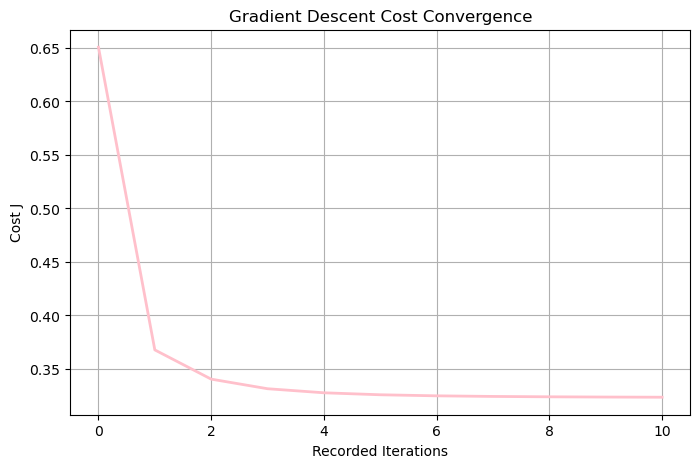


TRAIN Macro F1:       0.7510745299580861
TRAIN F1 (pos class): 0.5871690065311

TEST  Macro F1:       0.7514947171794911
TEST  F1 (pos class): 0.5857038657470528

Train Accuracy: 85.8998%
Test  Accuracy: 86.2102%


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math


df = pd.read_csv('bank-additional-full.csv', sep=';')


df['y'] = df['y'].map({'no': 0, 'yes': 1})


education_order = {
    "illiterate": 0,
    "basic.4y": 1,
    "basic.6y": 2,
    "basic.9y": 3,
    "high.school": 4,
    "professional.course": 5,
    "university.degree": 6,
    "unknown": 3
}
df['education'] = df['education'].map(education_order)


df = pd.get_dummies(
    df,
    columns=[
        "job", "marital", "default", "housing", "loan",
        "contact", "month", "day_of_week", "poutcome"
    ],
    drop_first=True
)


X = df.drop('y', axis=1).values
y = df['y'].values.reshape(-1, 1)

np.random.seed(40)
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

split = int(0.8 * X.shape[0])
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = X_train.astype(float)
X_test = X_test.astype(float)


def clip_outliers(X, low_p=1, high_p=99):
    low = np.percentile(X, low_p, axis=0)
    high = np.percentile(X, high_p, axis=0)
    return np.clip(X, low, high)

X_train = clip_outliers(X_train)
X_test = clip_outliers(X_test)


def zscore_normalize_features(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1.0
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_train, X_mu, X_sigma = zscore_normalize_features(X_train)
X_test = (X_test - X_mu) / X_sigma


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost_reg(X, y, w, b, lambda_, w_pos, w_neg):
    m = X.shape[0]
    z = np.dot(X, w) + b
    f_wb = sigmoid(z)

    eps = 1e-10
    f_wb = np.clip(f_wb, eps, 1 - eps)

    weights = np.where(y == 1, w_pos, w_neg)

    cost = (-1/m) * np.sum(
        weights * (y * np.log(f_wb) + (1 - y) * np.log(1 - f_wb))
    )

    reg_cost = (lambda_ / (2 * m)) * np.sum(w**2)
    return cost + reg_cost

def compute_gradient_reg(X, y, w, b, lambda_, w_pos, w_neg):
    m = X.shape[0]
    z = np.dot(X, w) + b
    f = sigmoid(z)

    weights = np.where(y == 1, w_pos, w_neg)
    err = (f - y) * weights

    dj_dw = (1/m) * np.dot(X.T, err) + (lambda_ / m) * w
    dj_db = (1/m) * np.sum(err)

    return dj_db, dj_dw

def gradient_descent(X, y, w, b, cost_func, grad_func,
                     alpha, num_iters, lambda_, w_pos, w_neg):

    J_hist = []
    for i in range(num_iters):
        dj_db, dj_dw = grad_func(X, y, w, b, lambda_, w_pos, w_neg)

        w -= alpha * dj_dw
        b -= alpha * dj_db

        if i % math.ceil(num_iters/10) == 0 or i == num_iters - 1:
            J = cost_func(X, y, w, b, lambda_, w_pos, w_neg)
            J_hist.append(J)
            print(f"Iteration {i:4}: Cost = {J:.6f}")

    return w, b, J_hist

def predict(X, w, b, threshold=0.5):
    probs = sigmoid(np.dot(X, w) + b)
    return (probs >= threshold).astype(int)


def f1_macro(y_true, y_pred):
    """
    Macro F1: average F1 over all classes.
    """
    classes = np.unique(y_true)
    f1s = []
    for cls in classes:
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))
        precision = tp / (tp + fp + 1e-10)
        recall    = tp / (tp + fn + 1e-10)
        f1 = 2 * precision * recall / (precision + recall + 1e-10)
        f1s.append(f1)
    return np.mean(f1s)

def f1_positive_class(y_true, y_pred):
 
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    precision = tp / (tp + fp + 1e-10)
    recall    = tp / (tp + fn + 1e-10)
    return 2 * precision * recall / (precision + recall + 1e-10)


w_pos = len(y_train) / (2 * np.sum(y_train == 1))
w_neg = len(y_train) / (2 * np.sum(y_train == 0))


m, n = X_train.shape
w = np.random.randn(n, 1) * 0.01
b = np.random.randn() * 0.01

alpha = 0.08
iterations = 1000
lambda_ = 0.1

w, b, J_history = gradient_descent(
    X_train, y_train, w, b,
    compute_cost_reg, compute_gradient_reg,
    alpha, iterations, lambda_, w_pos, w_neg
)


plt.figure(figsize=(8,5))
plt.plot(J_history, color='pink', linewidth=2)
plt.xlabel("Recorded Iterations")
plt.ylabel("Cost J")
plt.title("Gradient Descent Cost Convergence")
plt.grid(True)
plt.show()


y_pred_train = predict(X_train, w, b, threshold=0.5)
y_pred_test  = predict(X_test, w, b, threshold=0.5)

print("\nTRAIN Macro F1:      ", f1_macro(y_train, y_pred_train))
print("TRAIN F1 (pos class):", f1_positive_class(y_train, y_pred_train))

print("\nTEST  Macro F1:      ", f1_macro(y_test, y_pred_test))
print("TEST  F1 (pos class):", f1_positive_class(y_test, y_pred_test))

print("\nTrain Accuracy: %.4f%%" % (np.mean(y_pred_train == y_train) * 100))
print("Test  Accuracy: %.4f%%" % (np.mean(y_pred_test == y_test) * 100))
